# Benchmark v5 — GPU — BBBP — scaffold split, seed 0

**Task:** Binary classification — permeable (1) vs. non-permeable (0)
**Size:** ~2,039 molecules
**Metric:** ROC-AUC ↑

**Scaffold split**, seed **0** — GIN, D-MPNN, SchNet, LSTM with Optuna HPO.

Results go to `results/seed_0/scaffold/`.


In [1]:
# NOTE: autoreload is intentionally NOT enabled. With C-extension packages
# (numpy, torch, torch_geometric) `%autoreload 2` reloads them mid-run and
# corrupts their state (numpy RecursionError / torch_geometric circular
# import). If you edit the benchmark modules, restart the kernel instead.
import os
# Avoid XGBoost/OpenMP segfaults in Jupyter on macOS (OMP Error #179).
for _omp_var in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
    "NUMEXPR_NUM_THREADS",
):
    os.environ[_omp_var] = "1"

import sys
from pathlib import Path

ROOT = Path(".").resolve()
for _ in range(6):
    if (ROOT / "mol_repr_utils.py").exists():
        break
    ROOT = ROOT.parent
else:
    raise FileNotFoundError("Could not find benchmark_v5 root (mol_repr_utils.py)")
sys.path.insert(0, str(ROOT))

from mol_repr_utils import *
from split_utils import (
    get_or_create_splits, subset_array, subset_list, subset_graphs_by_valid_idx,
    check_split_proportions,
)
from conformer_generation import load_conformer_graphs
from hpo_utils import (
    hpo_tabular, hpo_gnn, hpo_schnet, hpo_lstm,
    save_hpo_params, hpo_params_path,
)
from hpo_config import SKLEARN_HPO_N_ITER

DATA_DIR = ROOT / "data"

DEVICE = get_device()
print(f"Benchmark v5 (GPU) code root: {ROOT}")
print(f"Device: {DEVICE}")
print("Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.")


INFO | Using device: cpu (request a GPU node on the cluster for large GNN/LSTM jobs)


Benchmark v5 (GPU) code root: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5
Device: cpu
Result paths are set in the next cell from SPLIT_SEED / SPLIT_MODE.


In [2]:
DATASET_SLUG = "bbbp"
TASK_TYPE = "classification"
OUT_CHANNELS = 1
BATCH_SIZE = 32
GNN_EPOCHS = 100
LSTM_EPOCHS = 100
TOX21_TABULAR = False

HPO_EPOCHS = 80  # Optuna trial length; GNN_EPOCHS for final refit
HPO_N_TRIALS = 20
print(f"GPU HPO tier: standard — {HPO_N_TRIALS} trials, {HPO_EPOCHS} epochs/trial, batch={BATCH_SIZE}")

SPLIT_MODE = "scaffold"   # "scaffold" or "random"
SPLIT_SEED = 0

RESULTS_ROOT = ROOT / "results" / f"seed_{SPLIT_SEED}" / SPLIT_MODE
RESULTS_DIR = RESULTS_ROOT / "gpu"
SPLITS_DIR = RESULTS_ROOT / "splits"
HPO_DIR = RESULTS_DIR / "hpo"
HISTORY_DIR = RESULTS_DIR / "histories"
for d in (RESULTS_DIR, SPLITS_DIR, HPO_DIR, HISTORY_DIR):
    d.mkdir(parents=True, exist_ok=True)
print(f"Results → {RESULTS_ROOT}")

PARTIAL_PATH = RESULTS_DIR / f"{DATASET_SLUG}_partial.json"
FRESH_RUN = False
HPO_N_ITER = SKLEARN_HPO_N_ITER

if FRESH_RUN:
    reset_dataset_run(
        DATASET_SLUG, RESULTS_DIR,
        results_root=RESULTS_ROOT, split_mode=SPLIT_MODE,
    )
    print("Fresh run — cleared partial results and splits.")

results = load_partial_results(PARTIAL_PATH)
if results:
    print(f"Resuming {len(results)} saved model(s): {', '.join(order_results(results).keys())}")
print(f"SPLIT_SEED={SPLIT_SEED}  mode={SPLIT_MODE}")


GPU HPO tier: standard — 20 trials, 80 epochs/trial, batch=32
Results → /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold
SPLIT_SEED=0  mode=scaffold


### Load data


In [3]:
import numpy as np
import pandas as pd

df = load_dataset("bbbp", cache_dir=DATA_DIR)
smiles, y = preprocess_dataset(df, "bbbp")
print(f"Molecules : {len(smiles)}")
print(f"Class balance: {np.bincount(y.astype(int))}")
smiles, y = filter_bonded_molecules(smiles, y)
print(f'After bond filter: {len(smiles)} molecules')


INFO | Loading 'bbbp' from cache: /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/data/bbbp.csv
[16:05:03] Explicit valence for atom # 1 N, 4, is greater than permitted
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] Explicit valence for atom # 6 N, 4, is greater than permitted
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] Explicit valence for atom # 6 N, 4, is greater than permitted
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydrogen atom without neighbors
[16:05:03] WARNING: not removing hydr

Molecules : 2039
Class balance: [ 479 1560]


[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not removing hydrogen atom without neighbors
[16:05:05] WARNING: not r

After bond filter: 2039 molecules


[16:05:06] WARNING: not removing hydrogen atom without neighbors
[16:05:06] WARNING: not removing hydrogen atom without neighbors


### Representations & scaffold split


In [4]:
graphs2d_all = smiles_to_graphs(smiles, y)
graphs_dmpnn_all = smiles_to_dmpnn_graphs(smiles, y)
X_tok_all, vocab = tokenize_smiles(smiles)

graphs3d_all, valid_idx_3d, _ = load_conformer_graphs(
    DATASET_SLUG, data_dir=DATA_DIR, n_confs=25
)
graphs3d_all = ensure_atomic_numbers_list(graphs3d_all)
print(f"3D graphs loaded: {len(graphs3d_all)} / {len(smiles)} (valid_idx mapping)")

split_data = get_or_create_splits(
    smiles, RESULTS_ROOT, DATASET_SLUG,
    mode=SPLIT_MODE, seed=SPLIT_SEED, force=FRESH_RUN,
)
train_idx = split_data["train_idx"]
val_idx = split_data["val_idx"]
test_idx = split_data["test_idx"]
check_split_proportions(train_idx, val_idx, test_idx, raise_on_fail=True)
print(split_data["summary"])

tr2d = subset_list(graphs2d_all, train_idx)
va2d = subset_list(graphs2d_all, val_idx)
te2d = subset_list(graphs2d_all, test_idx)

tr_dmpnn = subset_list(graphs_dmpnn_all, train_idx)
va_dmpnn = subset_list(graphs_dmpnn_all, val_idx)
te_dmpnn = subset_list(graphs_dmpnn_all, test_idx)

tr3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, train_idx)
va3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, val_idx)
te3d = subset_graphs_by_valid_idx(graphs3d_all, valid_idx_3d, test_idx)

tr_ds = SMILESDataset(subset_array(X_tok_all, train_idx), subset_array(y, train_idx))
va_ds = SMILESDataset(subset_array(X_tok_all, val_idx), subset_array(y, val_idx))
te_ds = SMILESDataset(subset_array(X_tok_all, test_idx), subset_array(y, test_idx))


[16:05:06] WARNING: not removing hydrogen atom without neighbors
[16:05:06] WARNING: not removing hydrogen atom without neighbors
[16:05:06] WARNING: not removing hydrogen atom without neighbors
[16:05:06] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:07] WARNING: not removing hydrogen atom without neighbors
[16:05:08] WARNING: not removing hydrogen atom without neighbors
[16:05:08] WARNING: not r

3D graphs loaded: 2038 / 2039 (valid_idx mapping)
{'n_total': 2039, 'n_train': 1631, 'n_val': 204, 'n_test': 204, 'n_scaffolds_total': 1025, 'n_scaffolds_train': 617, 'n_scaffolds_val': 204, 'n_scaffolds_test': 204}


### GIN (2D)


In [5]:
MODEL_KEY = "GIN (2D)"
tr = tr3d if "2D" == "3D" else tr2d
va = va3d if "2D" == "3D" else va2d
te = te3d if "2D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (2D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 2D — starting trial 1/20 (layers=5, hidden=192)


→ GIN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.5887 | val={'ROC-AUC': 0.7814942970652313, 'PRC-AUC': 0.8873213606636334}
INFO | HPO epoch   5/80 | loss=0.3811 | val={'ROC-AUC': 0.8178905549147764, 'PRC-AUC': 0.9130238825325148}
INFO | HPO epoch  10/80 | loss=0.3164 | val={'ROC-AUC': 0.8646674356016916, 'PRC-AUC': 0.9381338946146817}
INFO | HPO epoch  15/80 | loss=0.3157 | val={'ROC-AUC': 0.8631295655517109, 'PRC-AUC': 0.9375918971983919}
INFO | HPO epoch  20/80 | loss=0.2902 | val={'ROC-AUC': 0.8651800589516853, 'PRC-AUC': 0.9462635055365964}
INFO | HPO epoch  25/80 | loss=0.2378 | val={'ROC-AUC': 0.8826092528514674, 'PRC-AUC': 0.9535427727792494}
INFO | HPO epoch  30/80 | loss=0.2268 | val={'ROC-AUC': 0.8840189670639498, 'PRC-AUC': 0.9571567539509824}
INFO | HPO epoch  35/80 | loss=0.2257 | val={'ROC-AUC': 0.8723567858515955, 'PRC-AUC': 0.9491854466020355}
INFO | HPO epoch  40/80 | loss=0.1983 | val={'ROC-AUC': 0.8847879020889401, 'PRC-AUC': 0.954081001339028}
INFO | HPO epoch  45/80 | loss=0.1753 

   scaffold test: {'ROC-AUC': 0.8657011191573405, 'PRC-AUC': 0.9416094510117923}


### D-MPNN (2D)
Bond-centric directed MPNN (Yang et al. 2019).


In [6]:
MODEL_KEY = "D-MPNN (2D)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr_dmpnn, va_dmpnn, TASK_TYPE, "DMPNN", "2D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("DMPNN", "2D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr_dmpnn, va_dmpnn, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te_dmpnn, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_dmpnn.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | DMPNN 2D — starting trial 1/20 (layers=5, hidden=192)


→ D-MPNN (2D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.6420 | val={'ROC-AUC': 0.7623990772779701, 'PRC-AUC': 0.8474671993479341}
INFO | HPO epoch   5/80 | loss=0.4120 | val={'ROC-AUC': 0.7970011534025374, 'PRC-AUC': 0.8688198765404227}
INFO | HPO epoch  10/80 | loss=0.3922 | val={'ROC-AUC': 0.817762399077278, 'PRC-AUC': 0.8821109422711566}
INFO | HPO epoch  15/80 | loss=0.3533 | val={'ROC-AUC': 0.8259643726771754, 'PRC-AUC': 0.8928212290832895}
INFO | HPO epoch  20/80 | loss=0.3311 | val={'ROC-AUC': 0.8313469178521081, 'PRC-AUC': 0.8949209642508927}
INFO | HPO epoch  25/80 | loss=0.3228 | val={'ROC-AUC': 0.8496732026143792, 'PRC-AUC': 0.9191053060988144}
INFO | HPO epoch  30/80 | loss=0.2868 | val={'ROC-AUC': 0.8503139818018711, 'PRC-AUC': 0.9180356716639831}
INFO | HPO epoch  35/80 | loss=0.2644 | val={'ROC-AUC': 0.8614635396642316, 'PRC-AUC': 0.9304800053169254}
INFO | HPO epoch  40/80 | loss=0.2577 | val={'ROC-AUC': 0.8551839036268103, 'PRC-AUC': 0.9250715986917029}
INFO | HPO epoch  45/80 | loss=0.2536 

   scaffold test: {'ROC-AUC': 0.9095457537853852, 'PRC-AUC': 0.9579740379979473}


### GIN (3D)


In [7]:
MODEL_KEY = "GIN (3D)"
tr = tr3d if "3D" == "3D" else tr2d
va = va3d if "3D" == "3D" else va2d
te = te3d if "3D" == "3D" else te2d
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_gnn(
        tr, va, TASK_TYPE, "GIN", "3D", OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_gnn, PyGLoader, build_gnn, train_gnn
    model = build_gnn("GIN", "3D", OUT_CHANNELS,
                      hidden=best["hidden"], num_layers=best["num_layers"], dropout=best["dropout"])
    train_gnn(model, tr, va, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
              batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_gnn(model, PyGLoader(te, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    hist_name = "GIN (3D)".replace(" ", "_").replace("(", "").replace(")", "")
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_{hist_name}.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | GIN 3D — starting trial 1/20 (layers=5, hidden=192)


→ GIN (3D) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.5962 | val={'ROC-AUC': 0.8119953863898501, 'PRC-AUC': 0.8846198587821799}
INFO | HPO epoch   5/80 | loss=0.3891 | val={'ROC-AUC': 0.8772267076765347, 'PRC-AUC': 0.9439764531997725}
INFO | HPO epoch  10/80 | loss=0.3497 | val={'ROC-AUC': 0.87120338331411, 'PRC-AUC': 0.9369493841701304}
INFO | HPO epoch  15/80 | loss=0.2817 | val={'ROC-AUC': 0.8144303473023197, 'PRC-AUC': 0.9053146880482387}
INFO | HPO epoch  20/80 | loss=0.2888 | val={'ROC-AUC': 0.869281045751634, 'PRC-AUC': 0.9412650174954862}
INFO | HPO epoch  25/80 | loss=0.2351 | val={'ROC-AUC': 0.8917083173138537, 'PRC-AUC': 0.9510248548705789}
INFO | Early stop at epoch 27 (patience=15)
INFO | GIN 3D HPO — trial 1/20 finished | val=-0.896963 | best=-0.896963
INFO | GIN 3D — starting trial 2/20 (layers=4, hidden=192)
INFO | HPO epoch   1/80 | loss=0.6467 | val={'ROC-AUC': 0.7831603229527105, 'PRC-AUC': 0.8849501542255082}
INFO | HPO epoch   5/80 | loss=0.3571 | val={'ROC-AUC': 0.813917723952326, 'PR

   scaffold test: {'ROC-AUC': 0.8699144173798552, 'PRC-AUC': 0.9451812163832473}


### SchNet (3D coords)
Uses atomic numbers + xyz from min-energy n=25 conformer.


In [8]:
MODEL_KEY = "SchNet (3D coords)"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_schnet(
        tr3d, va3d, TASK_TYPE, OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import eval_schnet, PyGLoader, build_schnet, train_schnet
    model = build_schnet(
        OUT_CHANNELS,
        hidden_channels=best["hidden_channels"],
        num_filters=best["num_filters"],
        num_interactions=best["num_interactions"],
        num_gaussians=best["num_gaussians"],
        cutoff=best["cutoff"],
    )
    train_schnet(model, tr3d, va3d, TASK_TYPE, epochs=GNN_EPOCHS, lr=best["lr"],
                 batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    te3d_schnet = ensure_atomic_numbers_list(te3d)
    test_metrics = eval_schnet(model, PyGLoader(te3d_schnet, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_schnet.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | SchNet — starting trial 1/20


→ SchNet (3D coords) (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=1.1963 | val={'ROC-AUC': 0.7593233371780085, 'PRC-AUC': 0.8764701821410106}
INFO | HPO epoch   5/80 | loss=0.4227 | val={'ROC-AUC': 0.7930283224400871, 'PRC-AUC': 0.8798703139254308}
INFO | HPO epoch  10/80 | loss=0.3787 | val={'ROC-AUC': 0.8144303473023197, 'PRC-AUC': 0.8868884415290181}
INFO | HPO epoch  15/80 | loss=0.3716 | val={'ROC-AUC': 0.8290401127771371, 'PRC-AUC': 0.9087434954289256}
INFO | HPO epoch  20/80 | loss=0.3272 | val={'ROC-AUC': 0.8348071254645649, 'PRC-AUC': 0.9056417313677055}
INFO | HPO epoch  25/80 | loss=0.3215 | val={'ROC-AUC': 0.8194284249647572, 'PRC-AUC': 0.8919523399425482}
INFO | HPO epoch  30/80 | loss=0.2985 | val={'ROC-AUC': 0.8219915417147251, 'PRC-AUC': 0.8932914198371035}
INFO | HPO epoch  35/80 | loss=0.2788 | val={'ROC-AUC': 0.8241701909521979, 'PRC-AUC': 0.892577702555409}
INFO | HPO epoch  40/80 | loss=0.2482 | val={'ROC-AUC': 0.8095604254773805, 'PRC-AUC': 0.8857089170443102}
INFO | Early stop at epoch 42 (patienc

   scaffold test: {'ROC-AUC': 0.881500987491771, 'PRC-AUC': 0.9549447704731966}


### SMILES LSTM
Canonical isomeric SMILES tokens.


In [9]:
MODEL_KEY = "SMILES LSTM"
results = load_partial_results(PARTIAL_PATH)
if MODEL_KEY in results:
    print(f"Skipping {MODEL_KEY}")
else:
    print(f"→ {MODEL_KEY} (Optuna {HPO_N_TRIALS} trials, {SPLIT_MODE} split) …")
    best, history = hpo_lstm(
        tr_ds, va_ds, TASK_TYPE, len(vocab), OUT_CHANNELS,
        n_trials=HPO_N_TRIALS, epochs=HPO_EPOCHS, batch_size=BATCH_SIZE, device=DEVICE,
        seed=SPLIT_SEED,
    )
    save_hpo_params(
        hpo_params_path(HPO_DIR, MODEL_KEY, DATASET_SLUG),
        best,
        dataset=DATASET_SLUG,
        model=MODEL_KEY,
        seed=SPLIT_SEED,
    )
    from mol_repr_utils import SmilesLSTM, eval_lstm, TorchLoader, train_lstm
    model = SmilesLSTM(len(vocab), embed_dim=best["embed_dim"], hidden_dim=best["hidden_dim"],
                       n_layers=best["n_layers"], out_channels=OUT_CHANNELS, dropout=best["dropout"])
    train_lstm(model, tr_ds, va_ds, TASK_TYPE, epochs=LSTM_EPOCHS, lr=best["lr"],
               batch_size=BATCH_SIZE, device=DEVICE, verbose=False)
    test_metrics = eval_lstm(model, TorchLoader(te_ds, batch_size=BATCH_SIZE), DEVICE, TASK_TYPE)
    metrics = {k: (v, 0.0) for k, v in test_metrics.items()}
    save_model_result(results, MODEL_KEY, metrics, PARTIAL_PATH,
                      history=history, history_path=HISTORY_DIR / f"{DATASET_SLUG}_lstm.json")
    print(f"   {SPLIT_MODE} test: {test_metrics}")


INFO | LSTM — starting trial 1/20


→ SMILES LSTM (Optuna 20 trials, scaffold split) …


INFO | HPO epoch   1/80 | loss=0.6028 | val={'ROC-AUC': 0.7761117518902987, 'PRC-AUC': 0.8896912305139892}
INFO | HPO epoch   5/80 | loss=0.4426 | val={'ROC-AUC': 0.8085351787773932, 'PRC-AUC': 0.9117898206558921}
INFO | HPO epoch  10/80 | loss=0.3689 | val={'ROC-AUC': 0.8201973599897475, 'PRC-AUC': 0.9042567505837824}
INFO | HPO epoch  15/80 | loss=0.3363 | val={'ROC-AUC': 0.8423683198769704, 'PRC-AUC': 0.9263333821935577}
INFO | HPO epoch  20/80 | loss=0.3112 | val={'ROC-AUC': 0.8631295655517109, 'PRC-AUC': 0.9423780063969618}
INFO | HPO epoch  25/80 | loss=0.2862 | val={'ROC-AUC': 0.8314750736896065, 'PRC-AUC': 0.9239106299529536}
INFO | HPO epoch  30/80 | loss=0.2660 | val={'ROC-AUC': 0.8540305010893247, 'PRC-AUC': 0.9399260910241574}
INFO | HPO epoch  35/80 | loss=0.2405 | val={'ROC-AUC': 0.8537741894143278, 'PRC-AUC': 0.9404623975423585}
INFO | HPO epoch  40/80 | loss=0.2276 | val={'ROC-AUC': 0.8532615660643343, 'PRC-AUC': 0.943297352468721}
INFO | HPO epoch  45/80 | loss=0.2195 

   scaffold test: {'ROC-AUC': 0.901909150757077, 'PRC-AUC': 0.955592654657278}


### Finalize GPU + merge


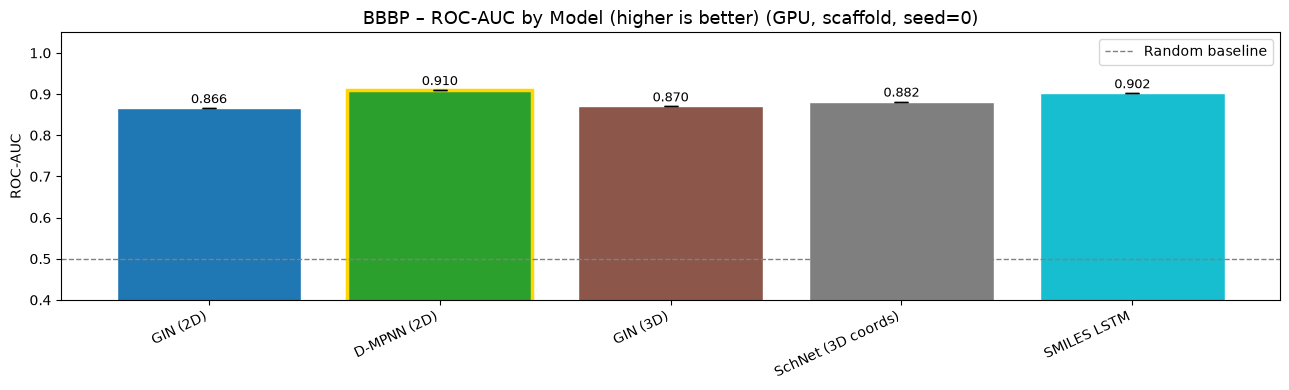

=== BBBP Results (5/12 models) ===
                            ROC-AUC          PRC-AUC
Model                                               
GIN (2D)            0.8657 ± 0.0000  0.9416 ± 0.0000
D-MPNN (2D)         0.9095 ± 0.0000  0.9580 ± 0.0000
GIN (3D)            0.8699 ± 0.0000  0.9452 ± 0.0000
SchNet (3D coords)  0.8815 ± 0.0000  0.9549 ± 0.0000
SMILES LSTM         0.9019 ± 0.0000  0.9556 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/bbbp_results.csv
Plot      : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/bbbp_auc_comparison.png
Partial   : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/gpu/bbbp_partial.json


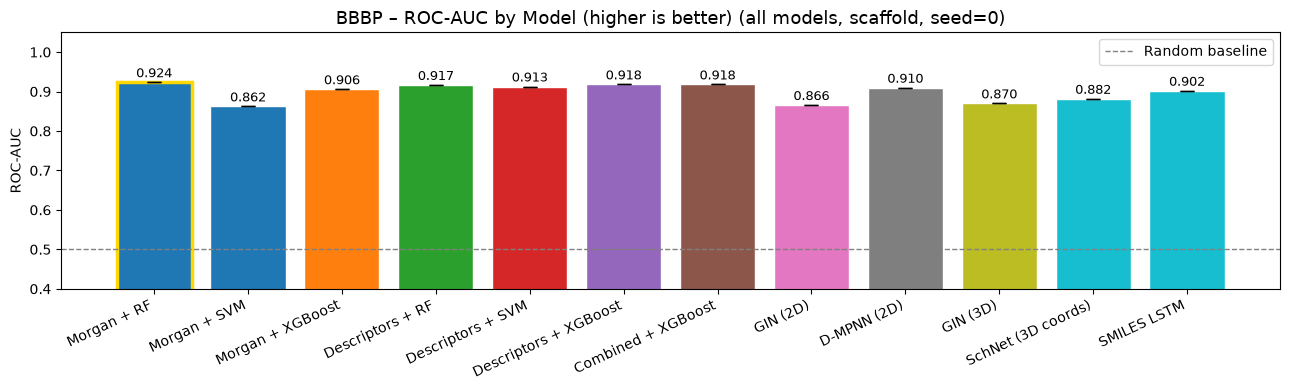

=== BBBP Results (12/12 models) ===
                               ROC-AUC          PRC-AUC
Model                                                  
Morgan + RF            0.9236 ± 0.0000  0.9731 ± 0.0000
Morgan + SVM           0.8623 ± 0.0000  0.9383 ± 0.0000
Morgan + XGBoost       0.9057 ± 0.0000  0.9553 ± 0.0000
Descriptors + RF       0.9165 ± 0.0000  0.9705 ± 0.0000
Descriptors + SVM      0.9127 ± 0.0000  0.9678 ± 0.0000
Descriptors + XGBoost  0.9181 ± 0.0000  0.9713 ± 0.0000
Combined + XGBoost     0.9180 ± 0.0000  0.9708 ± 0.0000
GIN (2D)               0.8657 ± 0.0000  0.9416 ± 0.0000
D-MPNN (2D)            0.9095 ± 0.0000  0.9580 ± 0.0000
GIN (3D)               0.8699 ± 0.0000  0.9452 ± 0.0000
SchNet (3D coords)     0.8815 ± 0.0000  0.9549 ± 0.0000
SMILES LSTM            0.9019 ± 0.0000  0.9556 ± 0.0000

Final CSV : /Users/emirerdem/Library/Mobile Documents/com~apple~CloudDocs/Projects/Thesis/molnet_esol_project/benchmark_v5/results/seed_0/scaffold/combined/bbbp_results.csv
Plot  

In [10]:
finalize_dataset_results(DATASET_SLUG, PARTIAL_PATH, RESULTS_DIR, TASK_TYPE,
    plot_title=f"BBBP – ROC-AUC by Model (higher is better) (GPU, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
cpu_partial = RESULTS_ROOT / "cpu" / f"{DATASET_SLUG}_partial.json"
if cpu_partial.exists():
    merge_combined_results(DATASET_SLUG, cpu_partial, PARTIAL_PATH, RESULTS_ROOT / "combined",
        TASK_TYPE, plot_title=f"BBBP – ROC-AUC by Model (higher is better) (all models, {SPLIT_MODE}, seed={SPLIT_SEED})", ylabel="ROC-AUC", minimize=False)
else:
    print("Run CPU notebook first for combined results.")
